# MEN 02 — Predicting Q_chosen from motion energy before the outcome

Does motion energy (ME) before the outcome predict the behavioral model's value of the chosen option,
Q_chosen, on each trial? Before the outcome the reward is not known, so the part of RPE
(= reward − Q_chosen) that video could carry is −Q_chosen.

The reward arrives at the first lick after the go cue, and the median response time (RT) is ~0.2 s.
ME is averaged in three windows before it:

- **−2…−1 s** and **−1…0 s** before the go cue;
- **−0.5…0 s before the first lick** (the response movement; for RT < 0.5 s it starts before the go cue).

All three windows have a fixed length. A window from the go cue to the first lick would be RT long,
so its mean would partly measure RT.

RT (log) is a behavioral readout of Q_chosen and is shown alongside ME.

1. ME and RT by Q_chosen tercile
2. Per-session correlation of Q_chosen with each ME window and with RT
3. Cross-validated prediction of Q_chosen
4. Numbers

Q_chosen and ME both drift over a session, and two series that drift correlate whatever their
trial-by-trial relation. Sections 2 and 3 therefore also compute each statistic with a
**session-permutation null** (Harris 2020): Q_chosen of one session against the predictors of
another session of the same animal and camera, both cut to the shorter session's trial count from the
start. This keeps each series' slow structure and breaks the pairing of trials. Each session's excess is
its own statistic minus the mean over its partner sessions, both computed on the same truncated trials.

Responded trials only (Q_chosen is undefined without a choice). Session values are averaged within
animal; tests are Wilcoxon signed-rank on animal means.

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import fip_utils as fu
import men_utils as mu
import signal_utils as su
import stats_utils as st
import plot_utils as pu
from plotstyle import apply_style, style_ax, save_fig, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="Degrees of freedom <= 0")
warnings.filterwarnings("ignore", message="Sample size too small for normal approximation")
warnings.filterwarnings("ignore", message="Exact p-value calculation does not work if there are zeros")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 200)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

# Trial and event tables: the CSV-curated FIP assets (as men_00)
ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
CACHE_PATH = ("/root/capsule/scratch/men_00/sessions.pkl" if IS_CO     # shared with men_00/men_01
              else os.environ.get("MEN_CACHE", "../../data/men_00_cache/sessions.pkl"))
FIG_DIR = "/root/capsule/scratch/figures/men" if IS_CO else "../data/figures/men"
SAVE_FIG = True

# ── Data (as men_00) ─────────────────────────────────────────────────────────
CAMERAS = ("BottomCamera", "SideCameraRight")
EXCLUDE_ACTIONS = ()
FS = 100.0                 # Hz
ME_NORM = "z"              # per session and camera

# ── Windows (s from the go cue) ──────────────────────────────────────────────
EARLY_WIN = (-2.0, -1.0)
LATE_WIN = (-1.0, 0.0)
LICK_WIN = (-0.5, 0.0)     # s from the first lick (the outcome)
MIN_TRIALS = 100           # responded trials per session and camera

# ── Cross-validation ─────────────────────────────────────────────────────────
N_FOLDS = 5                # contiguous blocks of trials

PREDICTORS = {"ME −2…−1 s": "me_early", "ME −1…0 s": "me_late", "ME −0.5…0 s lick": "me_lick",
              "log RT": "log_rt"}
SETS = {
    "ME −2…−1 s": ["me_early"],
    "ME −1…0 s": ["me_late"],
    "ME −0.5…0 s lick": ["me_lick"],
    "ME windows": ["me_early", "me_late", "me_lick"],
    "log RT": ["log_rt"],
    "ME windows + RT": ["me_early", "me_late", "me_lick", "log_rt"],
}

# ── Colors ───────────────────────────────────────────────────────────────────
CAM_LABEL = {"BottomCamera": "Bottom camera", "SideCameraRight": "Side camera"}
TERCILE_COLOR = {"low": OKABE_ITO["sky_blue"], "mid": OKABE_ITO["blue"], "high": "#002b4d"}
ME_COLOR = OKABE_ITO["reddish_purple"]
RT_COLOR = "0.45"
BOTH_COLOR = OKABE_ITO["vermillion"]
PRED_COLORS = [ME_COLOR] * 3 + [RT_COLOR]
SET_COLORS = [ME_COLOR] * 4 + [RT_COLOR, BOTH_COLOR]
rng = np.random.default_rng(0)

## 0. Data

The sessions of `men_00` (its cache), with each camera that passed the ME table's timing and image
screen. ME is z-scored per session and camera. One row per responded trial: Q_chosen, log RT and the
three window means.
Q_chosen is the value before the trial's update: RPE_earned = earned reward − Q_chosen on every
responded trial.

In [3]:
asset_roots = {}
for name, cands in ASSET_CANDIDATES.items():
    root = fu.find_asset_root(cands)
    if root:
        asset_roots[name] = root
assert asset_roots, "no FIP asset found; check ASSET_CANDIDATES"

me_index = fu.load_me_index(ME_DATA_ROOT)
inv = mu.inventory_sessions(asset_roots, me_index)
for cam in CAMERAS:
    inv[f"{cam}_used"] = (inv[f"{cam}_status"] == "ok") & ~inv[f"{cam}_action"].isin(EXCLUDE_ACTIONS)
inv["has_trials"] = inv["path"].notna()

sessions = mu.load_sessions(inv[inv.has_trials], fs=FS, cache_path=CACHE_PATH,
                            data_root=ME_DATA_ROOT, cameras=CAMERAS)
used = {(r.ses_idx, cam): bool(getattr(r, f"{cam}_used")) for r in inv.itertuples() for cam in CAMERAS}
for s in sessions:
    s["me_n"] = {cam: (mu.normalise(x, ME_NORM) if x is not None and used[(s["session"], cam)] else None)
                 for cam, x in s["me"].items()}
by_session = {s["session"]: s for s in sessions}
SUBJECTS = sorted({s["subject"] for s in sessions})


def trial_table(s, cam):
    # one row per responded trial: Q_chosen, log RT and the three ME window means
    x = s["me_n"][cam]
    if x is None:
        return None
    tr = s["trials"].reset_index(drop=True)
    cue = tr["goCue_start_time_in_session"].to_numpy()
    choice = tr["choice_time_in_session"].to_numpy()
    rt = choice - cue
    df = pd.DataFrame(dict(
        trial=tr["trial"], Q_chosen=tr["Q_chosen"], cue=cue, choice=choice,
        log_rt=np.log(np.where(rt > 0, rt, np.nan)),
        me_early=su.window_mean_grid(x, s["t0"], FS, cue, *EARLY_WIN),
        me_late=su.window_mean_grid(x, s["t0"], FS, cue, *LATE_WIN),
        me_lick=su.window_mean_grid(x, s["t0"], FS, choice, *LICK_WIN),   # before the first lick
    ))
    responded = (tr["animal_response"] < 2).to_numpy()
    df = df[responded & np.isfinite(df[["Q_chosen", *PREDICTORS.values()]]).all(axis=1)]
    if len(df) < MIN_TRIALS:
        return None
    df = df.reset_index(drop=True)
    df.insert(0, "subject", s["subject"])
    df.insert(1, "session", s["session"])
    return df


tables = {(s["session"], cam): t for s in sessions for cam in CAMERAS
          if (t := trial_table(s, cam)) is not None}
for cam in CAMERAS:
    sub = [t for (_, c), t in tables.items() if c == cam]
    print(f"{CAM_LABEL[cam]}: {len(sub)} sessions, {len({t.subject[0] for t in sub})} animals, "
          f"median {np.median([len(t) for t in sub]):.0f} responded trials")

  loaded 10 / 97


  loaded 20 / 97


  loaded 30 / 97


  loaded 40 / 97


  loaded 50 / 97


  loaded 60 / 97


  loaded 70 / 97


  loaded 80 / 97


  loaded 90 / 97


Bottom camera: 88 sessions, 9 animals, median 477 responded trials
Side camera: 64 sessions, 8 animals, median 488 responded trials


## 1. ME and RT by Q_chosen tercile

Responded trials split into Q_chosen terciles within each session. **a** ME around the go cue,
censored at the first lick so nothing after the outcome enters. **b** ME before the first lick.
**c** High − low tercile difference of each window's ME and of log RT, one point per animal.

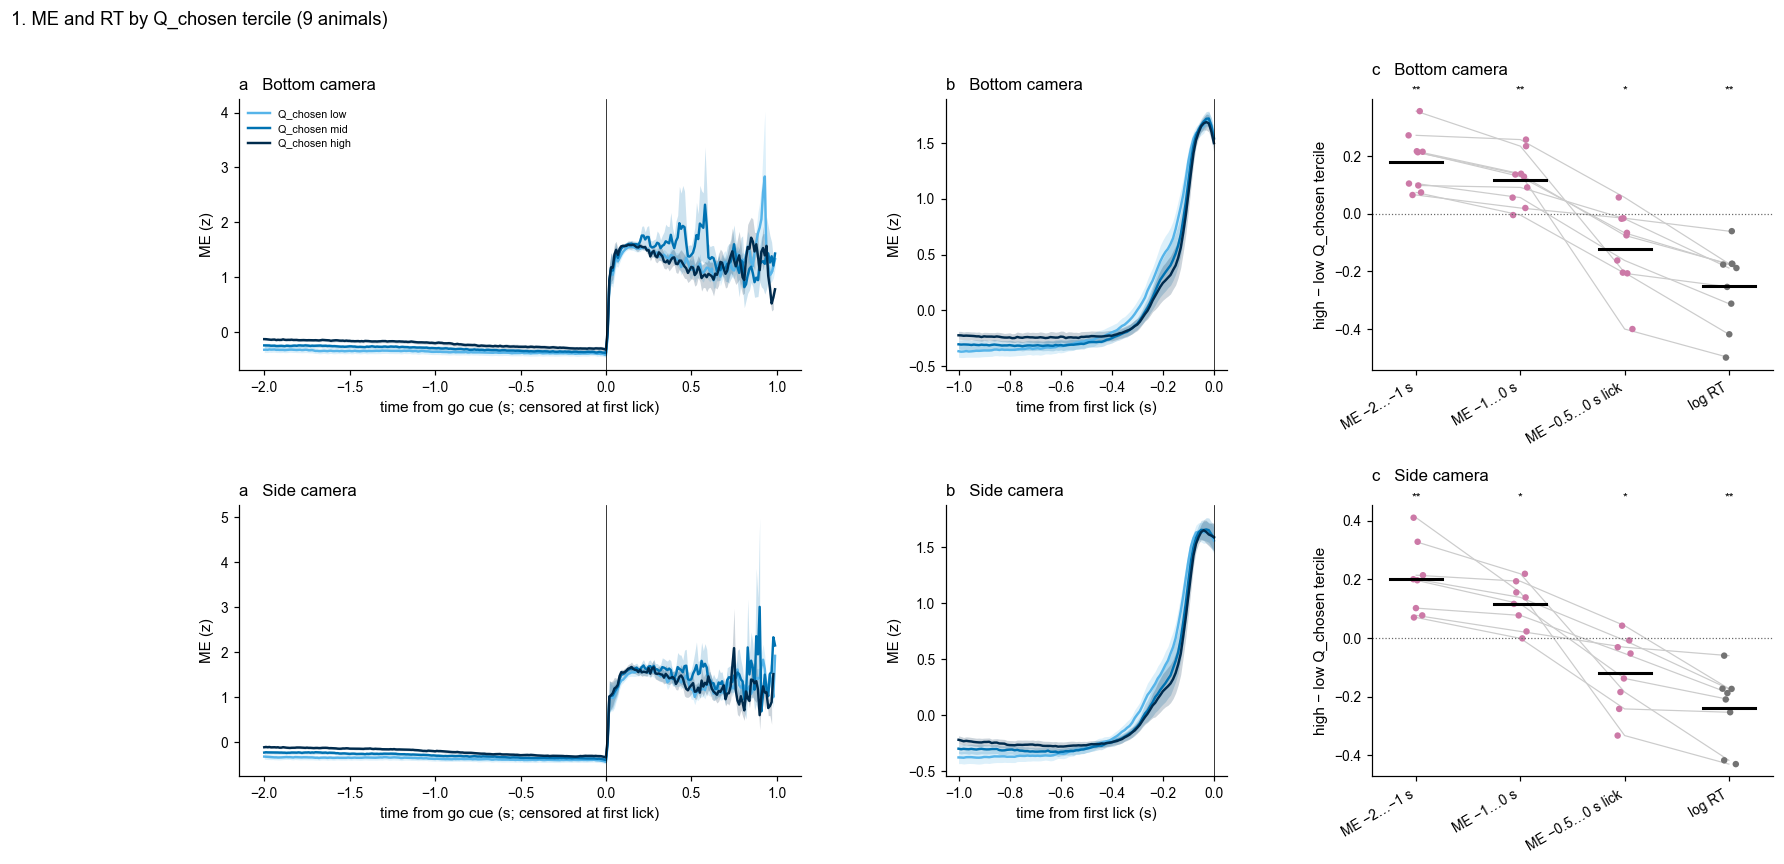

In [4]:
CUE_LAGS = np.arange(-2.0, 1.0 + 1e-9, 1 / FS)
LICK_LAGS = np.arange(-1.0, 0.0 + 1e-9, 1 / FS)
TERC = list(TERCILE_COLOR)

eta = {(cam, al, t): [] for cam in CAMERAS for al in ("cue", "lick") for t in TERC}
diff_rows = []
for (ses, cam), df in tables.items():
    s = by_session[ses]
    x = s["me_n"][cam]
    terc = pd.qcut(df.Q_chosen.rank(method="first"), 3, labels=TERC).to_numpy()
    seg_cue = su.peri_event_grid(x, s["t0"], FS, df.cue, CUE_LAGS, censor_after=df.choice)
    seg_lick = su.peri_event_grid(x, s["t0"], FS, df.choice, LICK_LAGS)
    for t in TERC:
        eta[(cam, "cue", t)].append((df.subject[0], np.nanmean(seg_cue[terc == t], 0)))
        eta[(cam, "lick", t)].append((df.subject[0], np.nanmean(seg_lick[terc == t], 0)))
    hi, lo = terc == "high", terc == "low"
    diff_rows.append(dict(subject=df.subject[0], session=ses, camera=cam,
                          **{lab: df[c][hi].mean() - df[c][lo].mean() for lab, c in PREDICTORS.items()}))
diffs = pd.DataFrame(diff_rows)


def animal_traces(per_session):
    subj, traces = zip(*per_session)
    return st.group_means(traces, subj)[1]


fig = plt.figure(figsize=(18, 8))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1.4, 0.7, 1], hspace=0.5, wspace=0.35, top=0.88)
for r, cam in enumerate(CAMERAS):
    for c, (al, lags, xlab) in enumerate((("cue", CUE_LAGS, "time from go cue (s; censored at first lick)"),
                                          ("lick", LICK_LAGS, "time from first lick (s)"))):
        ax = fig.add_subplot(gs[r, c])
        for t in TERC:
            pu.plot_mean_sem(ax, lags, animal_traces(eta[(cam, al, t)]), TERCILE_COLOR[t], f"Q_chosen {t}")
        ax.axvline(0, color="k", lw=0.5)
        ax.set_xlabel(xlab)
        ax.set_ylabel("ME (z)")
        ax.set_title(f"{'ab'[c]}   {CAM_LABEL[cam]}", loc="left")
        if c == 0 and r == 0:
            ax.legend(fontsize=7)
        style_ax(ax)
    ax = fig.add_subplot(gs[r, 2])
    a = st.animal_means(diffs[diffs.camera == cam], list(PREDICTORS), by_session=False)
    pu.strip_by_measure(ax, a, list(PREDICTORS), list(PREDICTORS), PRED_COLORS,
                        "high − low Q_chosen tercile", title=f"c   {CAM_LABEL[cam]}", rng=rng)
fig.suptitle(f"1. ME and RT by Q_chosen tercile ({len(SUBJECTS)} animals)", x=0.01, ha="left")
save_fig(fig, "men_02_1_terciles", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. Correlation with Q_chosen

Per session, the Pearson r of Q_chosen with each window's ME and with log RT over responded trials;
one point per animal (mean over its sessions). Stars: Wilcoxon signed-rank of the animal means
against 0. Each session is a separate replicate, so a consistent sign across animals is the test.

Left: r. Right: r minus the session-permutation null (Q_chosen of the session against the predictor
of each other session of the same animal).

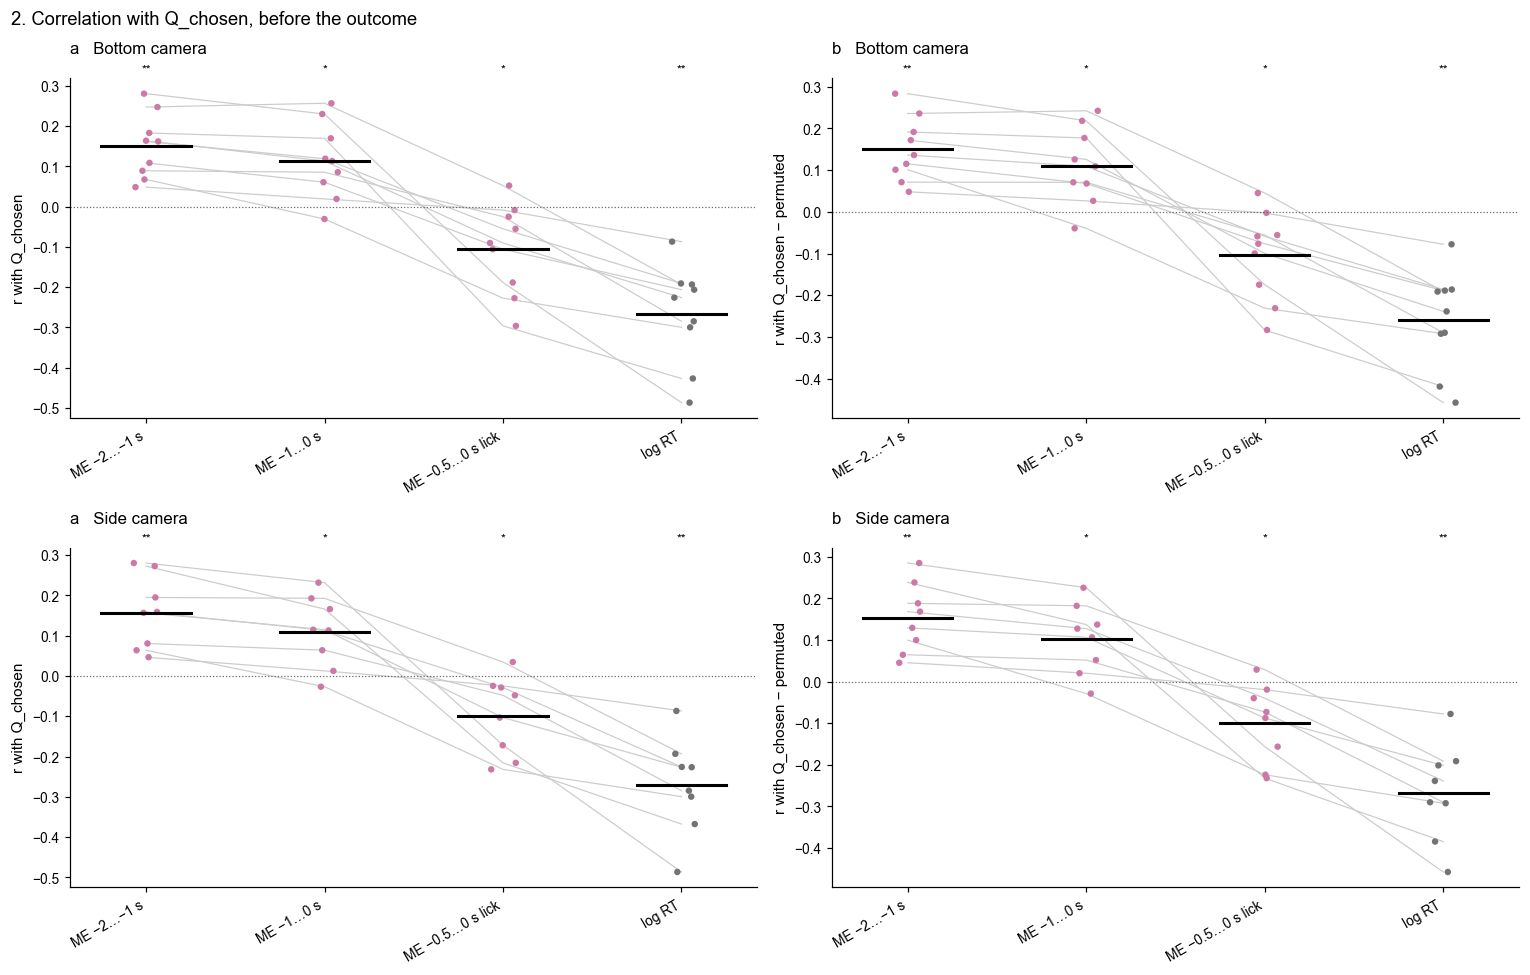

In [5]:
def pearson(x, y):
    return np.corrcoef(x, y)[0, 1]


def permuted(stat, key):
    # stat(predictors, Q_chosen) on the session itself and against each other session of the same animal
    # and camera, both cut to the shorter session's trials: (null mean, mean of own − partner)
    ses, cam = key
    df = tables[key]
    partners = [t for (s2, c2), t in tables.items() if c2 == cam and s2 != ses and t.subject[0] == df.subject[0]]
    own, null = [], []
    for other in partners:
        n = min(len(df), len(other))
        y = df.Q_chosen.to_numpy(float)[:n]
        own.append(stat(df.iloc[:n], y))
        null.append(stat(other.iloc[:n], y))
    own, null = np.array(own), np.array(null)
    return null.mean(), (own - null).mean()


corr_rows = []
for key, df in tables.items():
    for lab, c in PREDICTORS.items():
        stat = lambda d, y, c=c: pearson(d[c].to_numpy(float), y)
        r_null, r_excess = permuted(stat, key)
        corr_rows.append(dict(subject=df.subject[0], session=key[0], camera=key[1], predictor=lab,
                              r=stat(df, df.Q_chosen.to_numpy(float)), r_null=r_null, r_excess=r_excess))
corr = pd.DataFrame(corr_rows)


def per_animal(df, cam, cols, col_key, value):
    # animals x cols, mean over each animal's sessions
    w = df[df.camera == cam].pivot_table(index=["subject", "session"], columns=col_key,
                                         values=value).reset_index()
    return st.animal_means(w, cols, by_session=False)[cols]


def observed_and_excess(df, key, cols, colors, measure, ylabel, title, name):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for r, cam in enumerate(CAMERAS):
        for c, (value, lab) in enumerate(((measure, ylabel), (f"{measure}_excess", f"{ylabel} − permuted"))):
            pu.strip_by_measure(axes[r, c], per_animal(df, cam, cols, key, value), cols, cols, colors,
                                lab, title=f"{'ab'[c]}   {CAM_LABEL[cam]}", rng=rng)
    fig.suptitle(title, x=0.01, ha="left")
    fig.tight_layout()
    save_fig(fig, name, fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()


observed_and_excess(corr, "predictor", list(PREDICTORS), PRED_COLORS, "r", "r with Q_chosen",
                    "2. Correlation with Q_chosen, before the outcome", "men_02_2_corr")


## 3. Cross-validated prediction of Q_chosen

Per session: a least-squares fit of Q_chosen on each predictor set, trained on 4 of 5 contiguous
blocks of trials and tested on the fifth, for each block in turn. R² = 1 − (squared prediction error)
/ (variance of Q_chosen around the session mean). Blocks are contiguous because Q_chosen on
neighbouring trials is nearly the same, so randomly held-out trials would be predicted from their
neighbours.

R² is negative when the predictions are worse than the session mean. Each block is predicted around the
other blocks' mean Q_chosen, so a block whose Q_chosen sits at a different level is mispredicted by that
difference whatever the predictors. The permuted null has the same offset, so the excess (right) removes it.

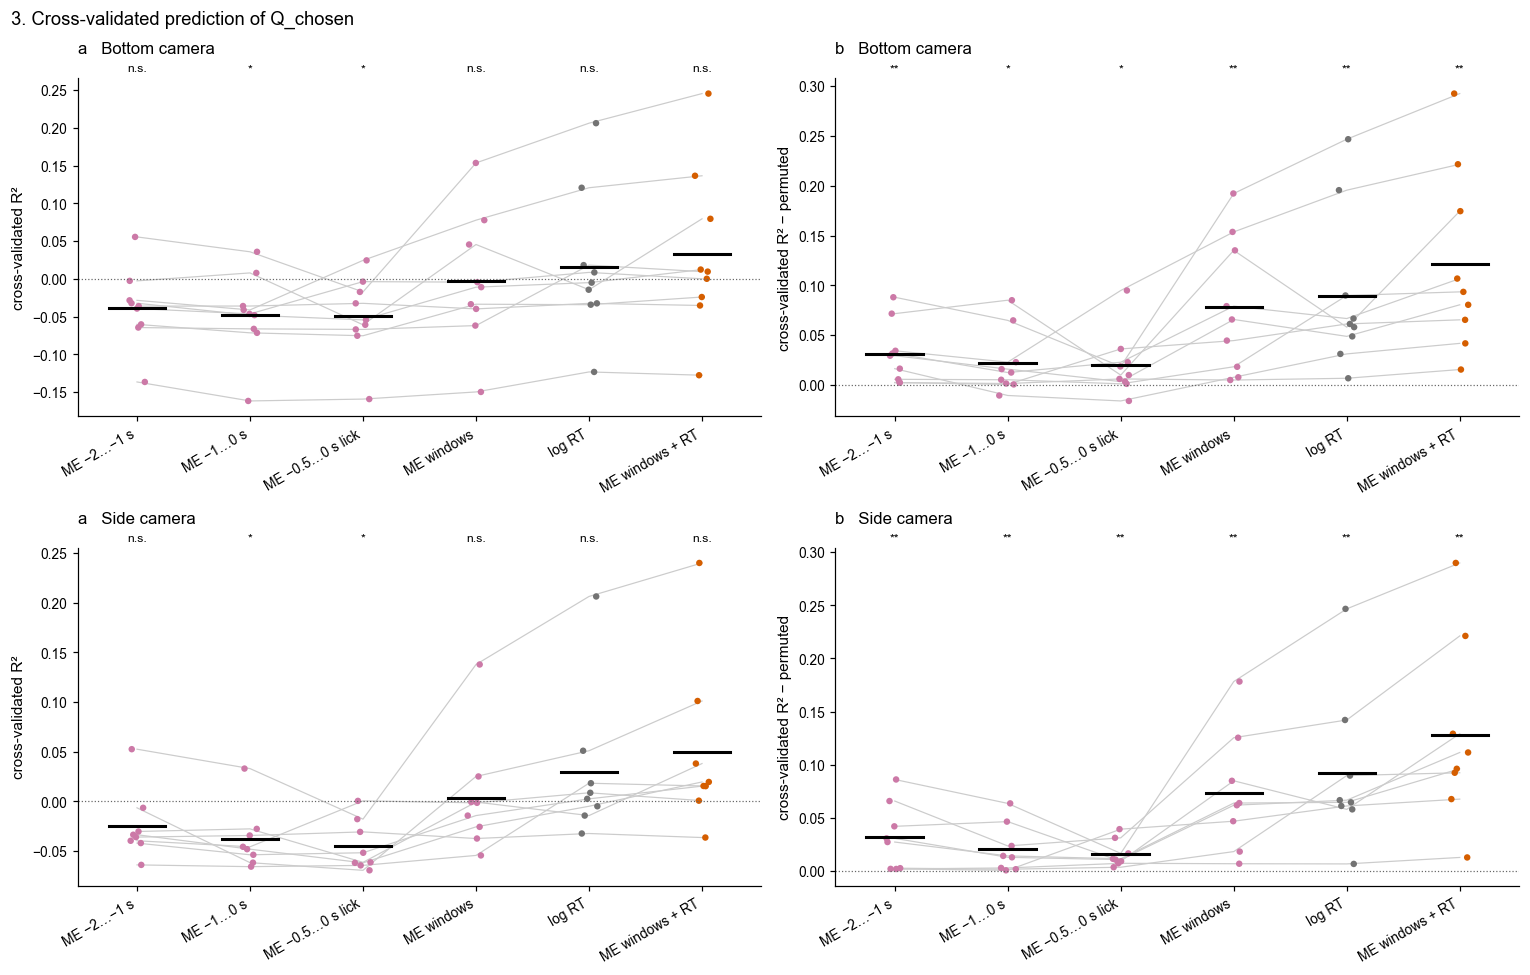

In [6]:
def cv_r2(X, y):
    # R² of least-squares predictions over N_FOLDS contiguous held-out blocks
    pred = np.empty(len(y))
    X1 = np.c_[np.ones(len(y)), X]
    for test in np.array_split(np.arange(len(y)), N_FOLDS):
        train = np.ones(len(y), bool)
        train[test] = False
        beta, *_ = np.linalg.lstsq(X1[train], y[train], rcond=None)
        pred[test] = X1[test] @ beta
    return 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)


cv_rows = []
for key, df in tables.items():
    for name, cols in SETS.items():
        stat = lambda d, y, cols=cols: cv_r2(d[cols].to_numpy(float), y)
        r2_null, r2_excess = permuted(stat, key)
        cv_rows.append(dict(subject=df.subject[0], session=key[0], camera=key[1], set=name,
                            r2=stat(df, df.Q_chosen.to_numpy(float)), r2_null=r2_null, r2_excess=r2_excess))
cv = pd.DataFrame(cv_rows)

observed_and_excess(cv, "set", list(SETS), SET_COLORS, "r2", "cross-validated R²",
                    "3. Cross-validated prediction of Q_chosen", "men_02_3_cv")


## 4. Numbers

Mean over animals, Wilcoxon p against 0, animals and sessions above 0, for each statistic, its
session-permutation null and the excess over the null.

In [7]:
def rows(df, key, cols, measure):
    out = []
    for cam in CAMERAS:
        a = per_animal(df, cam, cols, key, measure)
        sub = df[df.camera == cam]
        for c in cols:
            m, p, n = st.wilcoxon_animals(a[c])
            v = sub[sub[key] == c][measure]
            out.append(dict(camera=CAM_LABEL[cam], measure=f"{measure}: {c}", mean=round(m, 3), p=round(p, 4),
                            animals_above_0=f"{int((a[c] > 0).sum())}/{n}",
                            sessions_above_0=f"{(v > 0).sum()}/{len(v)}"))
    return out


numbers = pd.DataFrame([row for m in ("r", "r_null", "r_excess") for row in rows(corr, "predictor", list(PREDICTORS), m)]
                       + [row for m in ("r2", "r2_null", "r2_excess") for row in rows(cv, "set", list(SETS), m)])
numbers

,camera,measure,mean,p,animals_above_0,sessions_above_0
0,Bottom camera,r: ME −2…−1 s,0.150,0.0039,9/9,80/88
1,Bottom camera,r: ME −1…0 s,0.114,0.0117,8/9,78/88
2,Bottom camera,r: ME −0.5…0 s lick,-0.105,0.0195,1/9,24/88
3,Bottom camera,r: log RT,-0.267,0.0039,0/9,6/88
4,Side camera,r: ME −2…−1 s,0.157,0.0078,8/8,59/64
5,Side camera,r: ME −1…0 s,0.109,0.0234,7/8,57/64
6,Side camera,r: ME −0.5…0 s lick,-0.099,0.0391,1/8,20/64
7,Side camera,r: log RT,-0.271,0.0078,0/8,6/64
8,Bottom camera,r_null: ME −2…−1 s,0.002,0.9102,4/9,44/88
9,Bottom camera,r_null: ME −1…0 s,0.004,0.5703,5/9,43/88
